# Polarimetric images for selected mcfost runs


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pymcfost as mcfost
import os
import copy
import astropy
from astropy.io import fits
import numpy as np
import scipy
import pandas as pd
from astropy import units as u
import random
import distroi
import sys

sys.path.append(os.path.abspath(".."))  # parent of current working dir
import lib.Katya_func as kf

from typing import Literal, Tuple, Dict, Any

from distroi.auxiliary import constants
from distroi.data import image
from distroi.data import sed
from distroi.model.geom_comp import geom_comp
from distroi.auxiliary import select_data_oifits
from distroi.data.oi_container import OIContainer
from scipy.optimize import minimize_scalar
import scipy.optimize
import scipy.interpolate



    

#modelfolder='/fred/oz061/kandrych/mcfost_test/ar_pup/test_0/'
#pymcfost_dir = "/Users/katerynaandrych/Work/lin/Postdoc/ozstar/mcfost_modelling/iras08544-4431/corporaal_2023_models/pymcfost_test/"
pybads_dir = "/Users/katerynaandrych/Work/lin/Postdoc/ozstar/mcfost_modelling/iras08544-4431/pyVBMC_test/"
os.makedirs(pybads_dir, exist_ok=True)  # no error if it already exists

#interstellar reddening is applied as well on demand, can use different files here
reddening_law_path = '/Users/katerynaandrych/Work/lin/Postdoc/Data/SED_reddening/ISMreddening_law_Cardelli1989.dat'


folder_sim="zone_1_Rin_7.427237463455789_zone_1_edge_0.004934787489609_zone_1_Rc_25.4174232834861_"
simulation_dir = pybads_dir+folder_sim+"/"

print (f" parameters in folder {folder_sim}")


# Load original file
pf = kf.ParaFile(pybads_dir+"simulation.para")
# Show current parameters
incl=float(pf.params["imin"])
print(f"Inclination: {incl} deg")
pa=float(pf.params["disk_pa"])
print(f"Position angle: {pa} deg")


/opt/anaconda3/envs/interferometry/lib/python3.12/site-packages/pymcfost/SED.py:10: UserWarning: mpl_scatter_density is not present
  warnings.warn("mpl_scatter_density is not present", UserWarning)


 parameters in folder zone_1_Rin_7.427237463455789_zone_1_edge_0.004934787489609_zone_1_Rc_25.4174232834861_
Inclination: 19.0 deg
Position angle: 6.0 deg


### Checking MCFOST output header and resolution

In [2]:
#open the required ray-traced SED fits file
hdul=fits.open(simulation_dir+'data_1.63/RT.fits.gz')
print(hdul[0].header)
print('pixel scale '+str(hdul[0].header['CDELT2']*3600*1000)+ ' mas/pixel')
print('max size '+str(hdul[0].header['NAXIS1'])+' pixels')
size_res=hdul[0].header['NAXIS1']*hdul[0].header['CDELT2']*3600*1000
print('max size '+str(size_res)+' mas')
distance = 1220.0  # distance in pc
size_res_au=kf.mas2au(size_res, distance)
print('max size in au '+ str(size_res_au)) #4.44 is distance in kpc


SIMPLE  =                    T / file does conform to FITS standard             BITPIX  =                  -32 / number of bits per data pixel                  NAXIS   =                    5 / number of data axes                            NAXIS1  =                  512 / length of data axis 1                          NAXIS2  =                  512 / length of data axis 2                          NAXIS3  =                    1 / length of data axis 3                          NAXIS4  =                    1 / length of data axis 4                          NAXIS5  =                    8 / length of data axis 5                          EXTEND  =                    T / FITS dataset may contain extensions            COMMENT   FITS (Flexible Image Transport System) format is defined in 'AstronomyCOMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H WAVE    =                 1.63 / wavelength [microns]                           CTYPE1  = 'RA---TAN'                    

## Polarimetric test

In [3]:

import subprocess

plt.rc('font',   size=14)          # controls default text sizes
plt.rc('axes',   titlesize=16)     # fontsize of the axes title
plt.rc('axes',   labelsize=16)     # fontsize of the x and y labels
plt.rc('xtick',  labelsize=12)     # fontsize of the tick labels
plt.rc('ytick',  labelsize=12)     # fontsize of the tick labels
plt.rc('legend', fontsize=14)      # legend fontsize
plt.rc('figure', titlesize=16)     # fontsize of the figure title




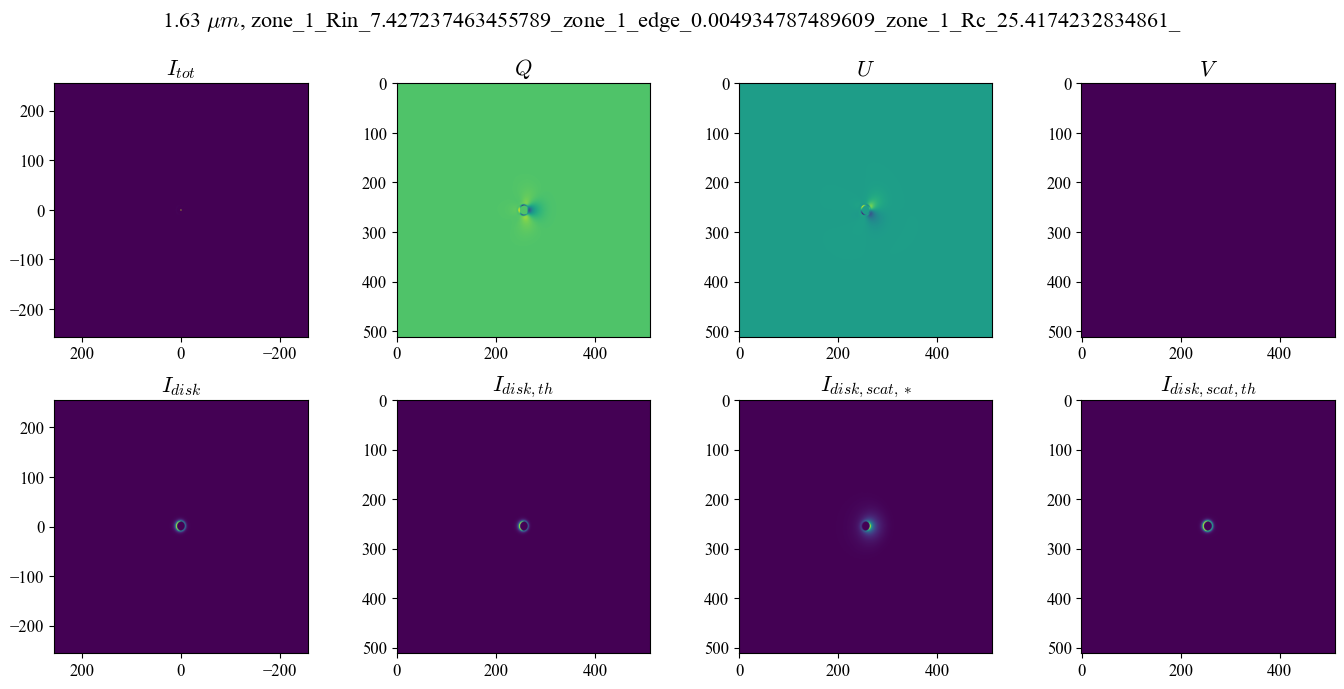

(512, 512)
0.64036872


In [4]:


fig_dir = simulation_dir+"polarimetric/"
os.makedirs(fig_dir, exist_ok=True)  # no error if it already exists

img_array, header, img_tot, img_q, img_u, img_v, img_star, img_star_sct, img_disk_th, img_disk_th_sct = kf.load_mcfost_images_1wave(simulation_dir, '1.63',ploting=True, save_plots=fig_dir, title_addition=folder_sim)



pi_sum = np.sum(np.sqrt(img_q**2 + img_u**2))
pi_frac = pi_sum/np.sum(img_tot)
print(img_q.shape)
pixel_scale=header['CDELT2']*u.deg.to(u.arcsec)*1000 

print(pixel_scale)
 

Simulation MCFOST
sum Q_phi: -1.1413166224702585e-13, sum U_phi: 4.3006501035293057e-16, sum PI: 1.6131320996863596e-13, sum I: 4.519289456550446e-11
frac in % Q_phi:-0.2525433773258287, frac U_phi:0.000951620856525524, frac PI: 0.3569437563419342
Rescaling to instrument pixel scale
new shape:(91, 91), 1/coefficient: 5.621761162850053
sum Q_phi: -1.1218897311259577e-13, sum U_phi: 4.1552110544561874e-16, sum PI: 1.5208477664906753e-13, sum I: 4.879433823653029e-11
frac Q_phi:-0.22992211221056083, frac U_phi:0.000851576474777427, frac PI: 0.3116852941253909


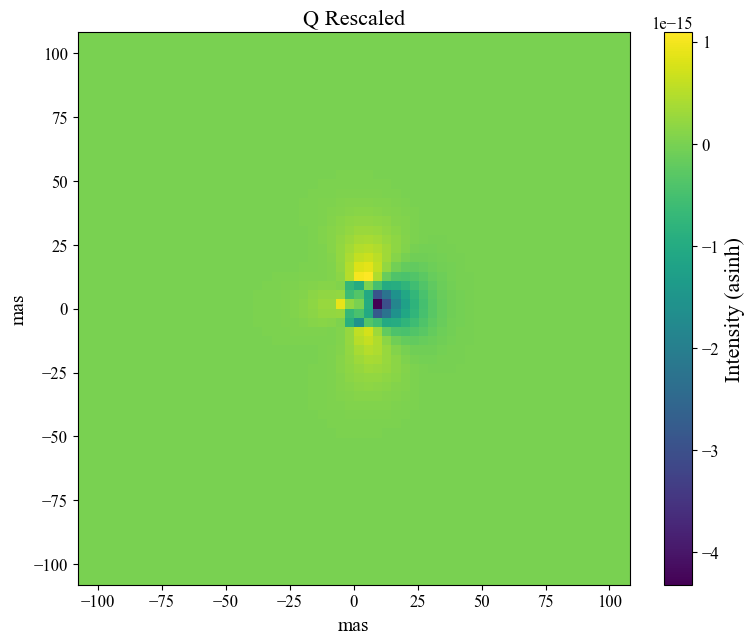

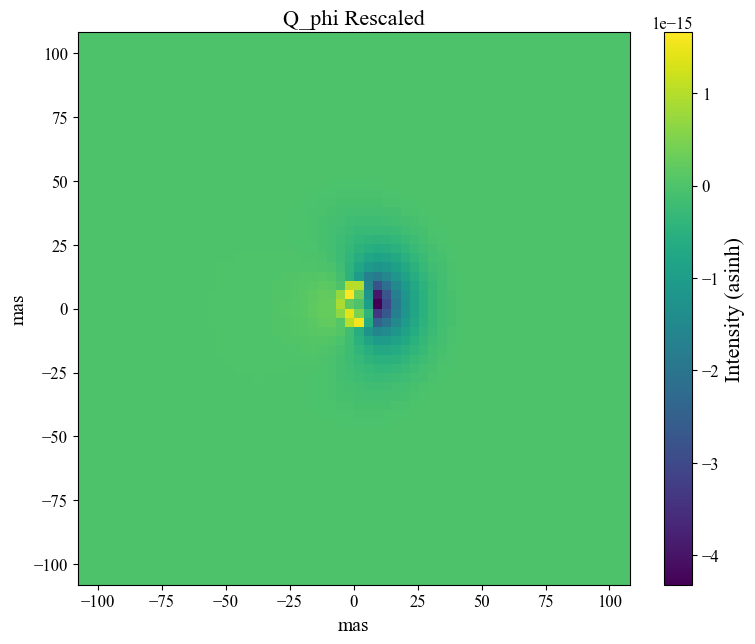

Convolving with synthetic PSF
PSF FWHM: 30 mas
PSF shape: (53, 53), PSF sum: 1.0000000000000002
new shape after convolution: (91, 91)


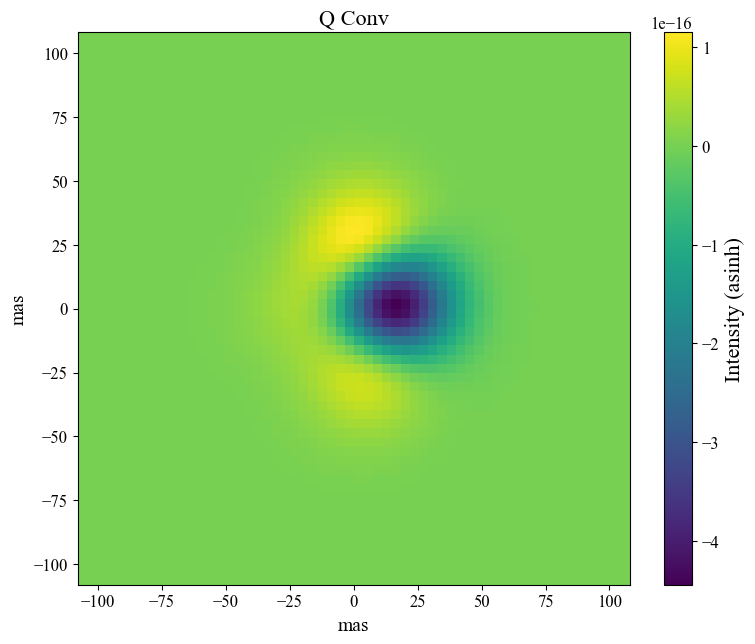

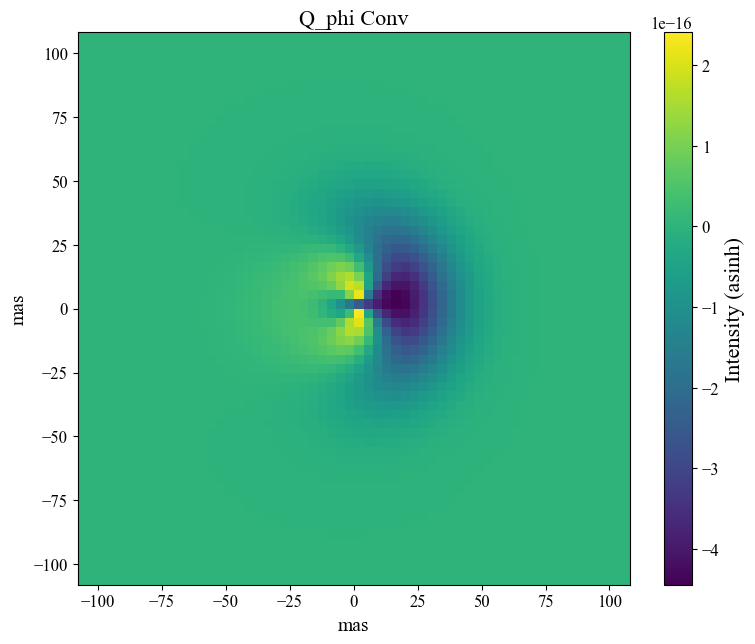

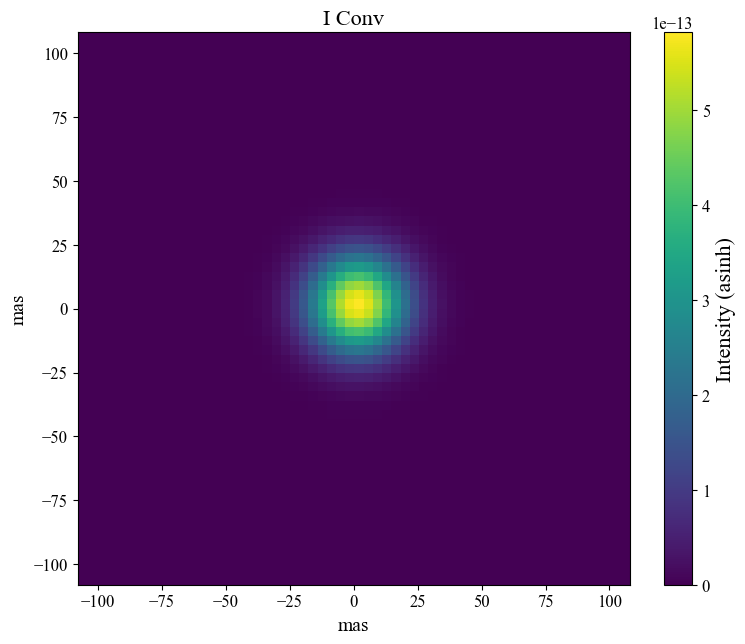

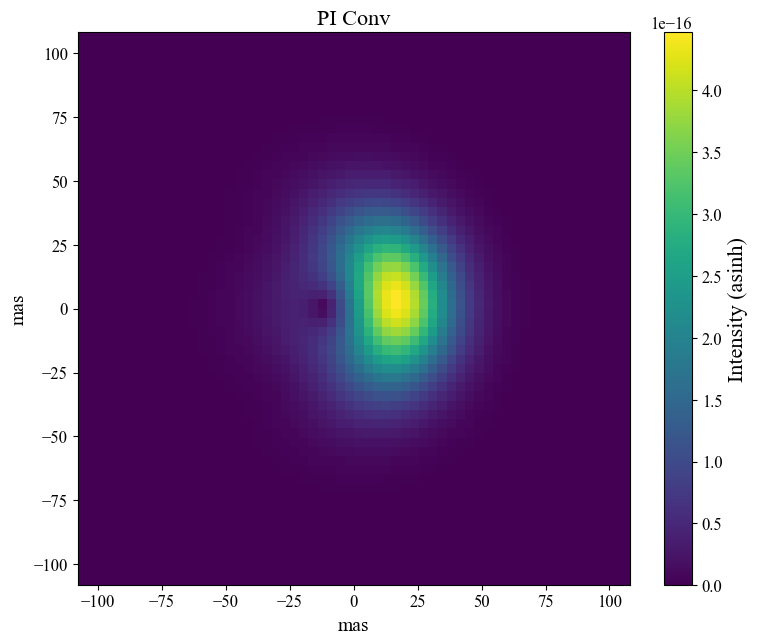

sum Q_phi: -4.6815e-14, sum U_phi: -7.13555e-18, sum PI: 7.8551e-14
frac PI:   0.161 %
frac Qφ:   -0.096 %
frac Uφ:   -0.000 %
{'sum_PI': 7.855102557618848e-14, 'sum_I': 4.879433823653027e-11, 'sum_Q': -1.556271263573163e-14, 'sum_U': -3.3169272585543506e-15, 'sum_Q_phi': -4.681500586228507e-14, 'sum_U_phi': -7.135550543064585e-18, 'frac_PI_over_I': 0.0016098389365465484, 'frac_Qphi_over_I': -0.0009594352040466171, 'frac_Uphi_over_I': -1.4623726442348793e-07, 'frac_Qphi_over_PI': -0.5959821086852405, 'roi_pixels': 8281, 'roi_pixels_I': 8281, 'roi_half_size': None, 'roi_half_size_tot_int': None}
Convolving with real PSF from observations
PSF shape: (200, 200), PSF sum: 1.0
new shape after convolution: (91, 91)


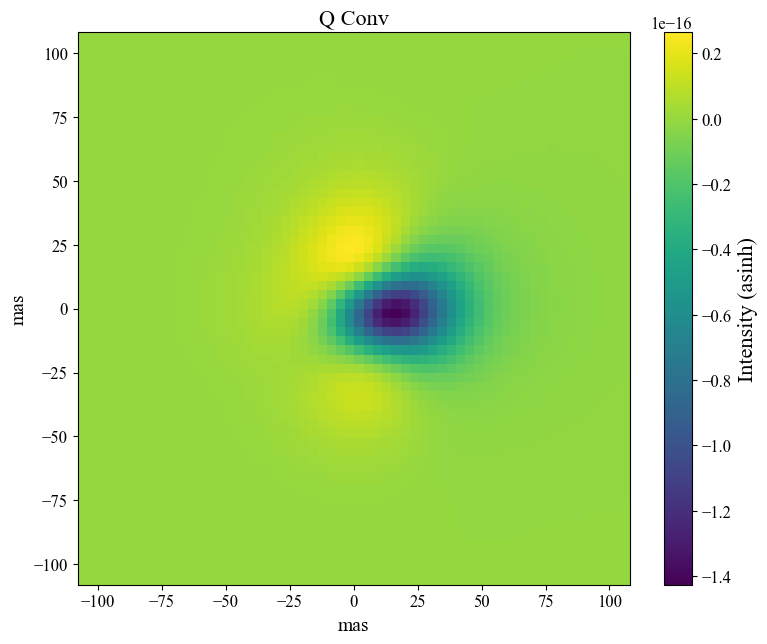

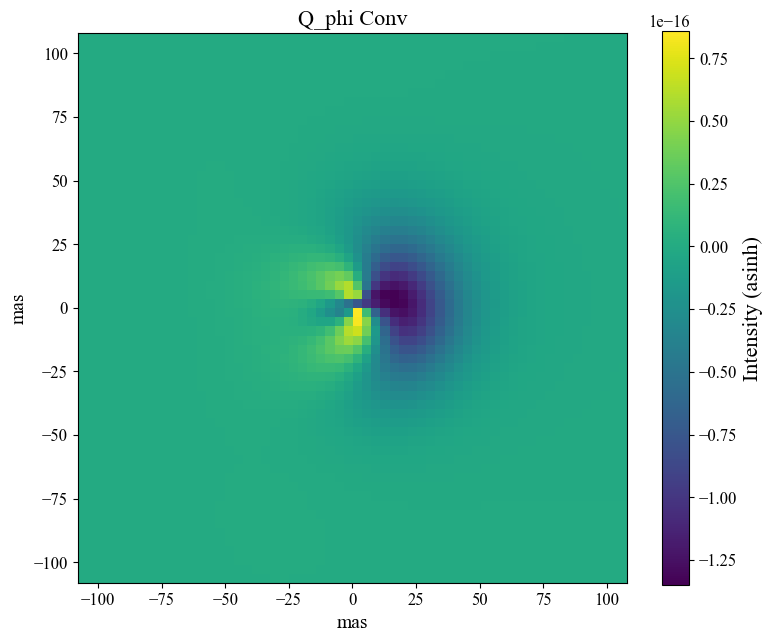

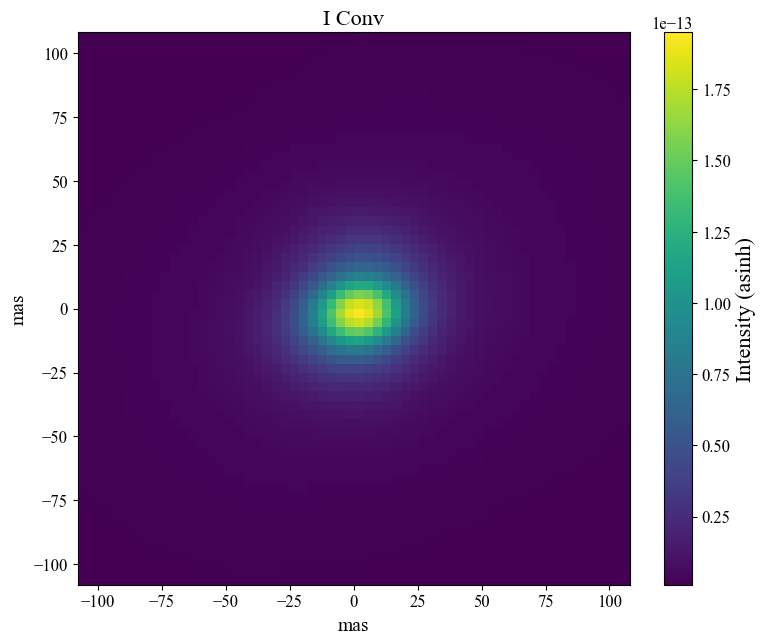

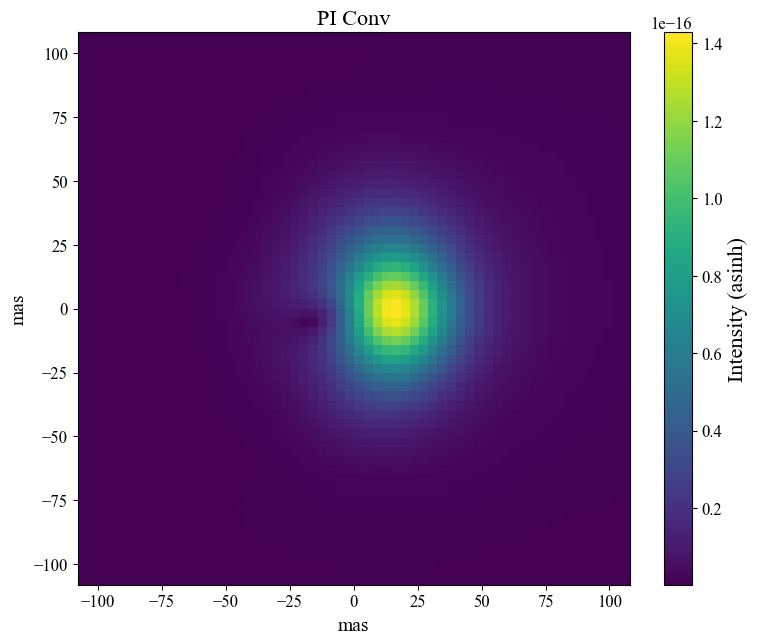

sum Q_phi: -1.55518e-14, sum U_phi: -2.73972e-15, sum PI: 2.93157e-14
frac PI:   0.087 %
frac Qφ:   -0.046 %
frac Uφ:   -0.008 %
{'sum_PI': 2.931567685385982e-14, 'sum_I': 3.369307137056606e-11, 'sum_Q': -1.0749208058530047e-14, 'sum_U': -2.3045689535697767e-15, 'sum_Q_phi': -1.5551812158006422e-14, 'sum_U_phi': -2.739721733293655e-15, 'frac_PI_over_I': 0.0008700802764888247, 'frac_Qphi_over_I': -0.0004615730037479555, 'frac_Uphi_over_I': -8.131409877008272e-05, 'frac_Qphi_over_PI': -0.5304947327511152, 'roi_pixels': 8281, 'roi_pixels_I': 8281, 'roi_half_size': None, 'roi_half_size_tot_int': None}


In [5]:
from skimage.transform import rescale, resize, downscale_local_mean
from astropy.convolution import Gaussian2DKernel, convolve, convolve_fft, AiryDisk2DKernel



band='I'
if band=='I':
    ps=3.6
    psf_FWHM=30 #mas
elif band=='V':
    ps=3.6
    psf_FWHM=30 #mas
elif band=='H':
    ps=12.27
    psf_FWHM=40

print('Simulation MCFOST')
R_mcfost, x, y, X, Y=kf.compute_grid(img_q)
#calculating angle for azimuthal polarisation

q_phi, u_phi, pi, phi_mcfost=kf.compute_qphi_uphi_pi(img_q, img_u)

pi_sum = np.sum(pi)
pi_frac = pi_sum/np.sum(img_tot)

print(f'sum Q_phi: {np.sum(q_phi)}, sum U_phi: {np.sum(u_phi)}, sum PI: {pi_sum}, sum I: {np.sum(img_tot)}')
print(f'frac in % Q_phi:{np.sum(q_phi)/np.sum(img_tot)*100}, frac U_phi:{np.sum(u_phi)/np.sum(img_tot)*100}, frac PI: {pi_frac*100}')

# kf.plot_polarimetric_image(img_q, pixel_scale, title='Q MCFOST', roi_half_size=int(30*ps/pixel_scale), image_scale="asinh", save=False, show=True)
# kf.plot_polarimetric_image(q_phi, pixel_scale, title='Q_phi MCFOST', roi_half_size=int(30*ps/pixel_scale), image_scale="asinh", save=False, show=True)
# kf.plot_polarimetric_image(pi, pixel_scale, title='PI MCFOST', roi_half_size=int(30*ps/pixel_scale), image_scale="asinh", save=False, show=True)


# kf.plot_polarimetric_image(img_star_sct, pixel_scale, title='disc_scattered', roi_half_size=50, image_scale="asinh", save=False, show=True)

print('Rescaling to instrument pixel scale')

img_q_rescaled, img_u_rescaled, img_total_rescaled, q_phi_rescaled, u_phi_rescaled, pi_rescaled, phi_rescaled=kf.rescale_and_recalculate_all_polarim_img(img_q, img_u, img_tot, pixel_scale, instrument='zimpol', conserve='sum')
pi_rescaled_sum = np.sum(pi_rescaled)
pi_rescaled_frac = pi_rescaled_sum/np.sum(img_total_rescaled)
print(f'new shape:{img_q_rescaled.shape}, 1/coefficient: {ps/pixel_scale}')

print(f'sum Q_phi: {np.sum(q_phi_rescaled)}, sum U_phi: {np.sum(u_phi_rescaled)}, sum PI: {pi_rescaled_sum}, sum I: {np.sum(img_total_rescaled)}')
print(f'frac Q_phi:{np.sum(q_phi_rescaled)/np.sum(img_total_rescaled)*100}, frac U_phi:{np.sum(u_phi_rescaled)/np.sum(img_total_rescaled)*100}, frac PI: {pi_rescaled_frac*100}')

kf.plot_polarimetric_image(img_q_rescaled, ps, title='Q Rescaled', roi_half_size=30, image_scale="asinh", save=False, show=True)
kf.plot_polarimetric_image(q_phi_rescaled, ps, title='Q_phi Rescaled', roi_half_size=30, image_scale="asinh", save=False, show=True)



# Convolving with synthetic PSF
kernel, Q_conv, U_conv, I_conv, PI_conv, Q_phi_conv, U_phi_conv=kf.convolve_polarimetric_images(img_q_rescaled, img_u_rescaled, img_total_rescaled, ps,psf_source='synthetic', psf_fwhm_mas=psf_FWHM)
metrics=kf.polarimetric_metrics(I_conv,Q_conv, U_conv, Q_phi_conv, U_phi_conv,PI_conv)
print(metrics)


# Convolving with real PSF from observations
star_psf='HD83878'
figfolder_psf='/Users/katerynaandrych/Work/lin/PhD/SPHERE_reduction_data/paper2/mean_combined/'+star_psf+'/'
file_psf=star_psf+'_'+'V'+'_'+'I'+'_meancombined.fits'

kernel, Q_conv, U_conv, I_conv, PI_conv, Q_phi_conv, U_phi_conv=kf.convolve_polarimetric_images(img_q_rescaled, img_u_rescaled, img_total_rescaled, ps,psf_source='file', psf_file=file_psf, folder_psf=figfolder_psf, psf_cut=100, )

metrics=kf.polarimetric_metrics(I_conv,Q_conv, U_conv, Q_phi_conv, U_phi_conv,PI_conv)
print(metrics)





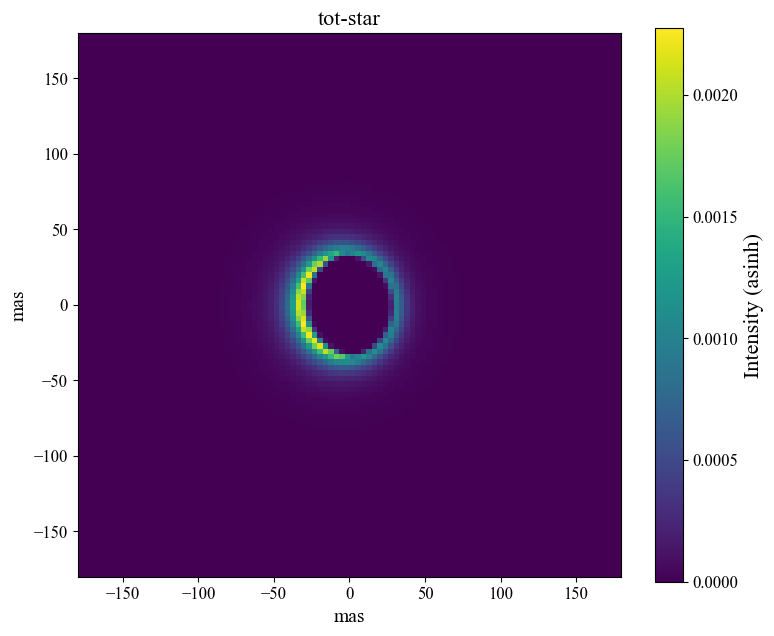

In [6]:
kf.plot_polarimetric_image((img_tot-img_star)/np.sum(img_tot), ps, title="tot-star", roi_half_size=50, image_scale='asinh', show=True )
#plot_polarimetric_image(pi_conv, ps, title='PI Conv', roi_half_size=100, image_scale="asinh", save=False, show=True)


0.3832129968761416
3.703835794188337
33.19448467967747


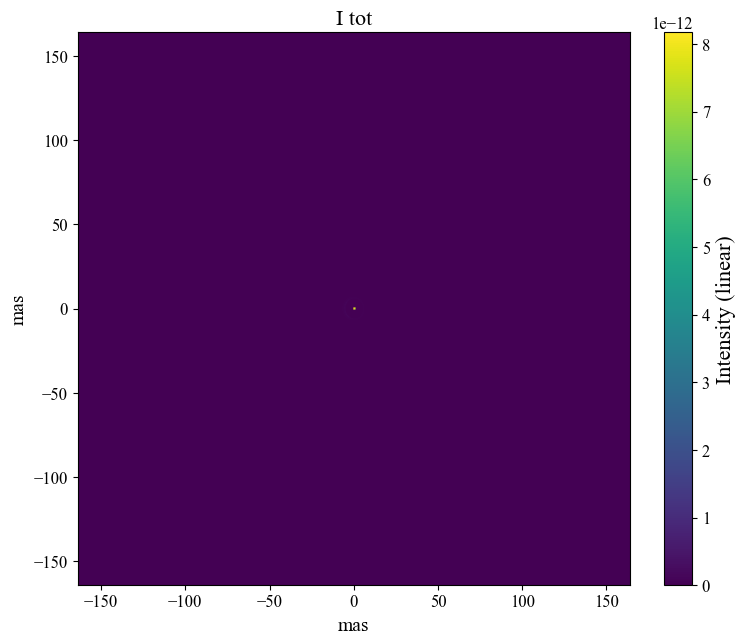

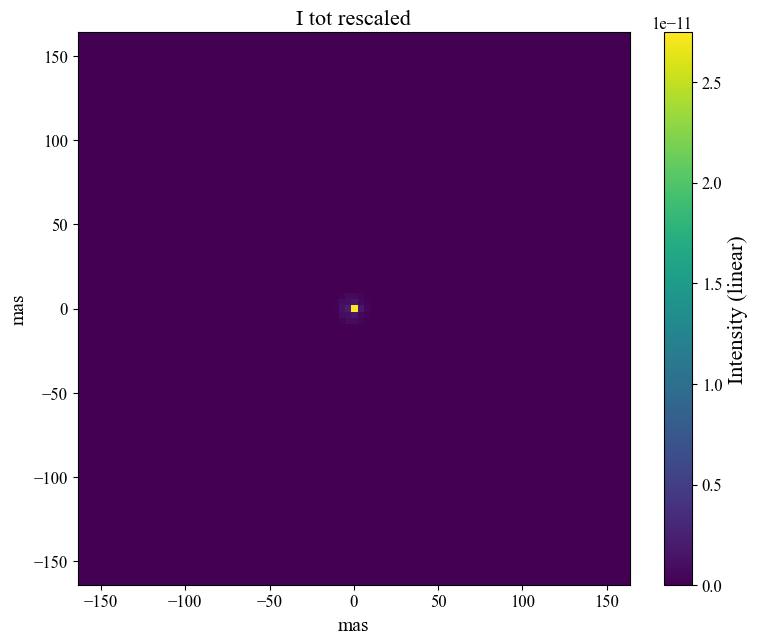

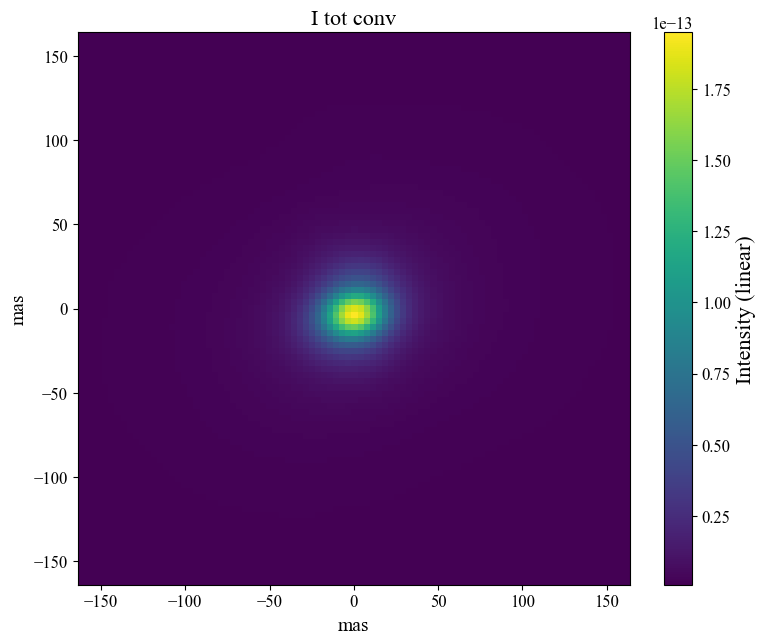

Unresolved pol: 0.060796629984444746 %, angle: 91.19396654751536 deg
Unresolved pol after conv: 0.04409526220684481 %, angle: 108.63842891810087 deg


In [7]:
from astropy.io import fits
from skimage.measure import EllipseModel
from matplotlib.patches import Ellipse
from scipy import interpolate
from mpl_toolkits.axes_grid1 import make_axes_locatable
import math
from textwrap import wrap
import scipy.ndimage as ndimage
from matplotlib.gridspec import GridSpec
from matplotlib import colors
import pandas as pd
from scipy.optimize import curve_fit
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
from matplotlib.font_manager import FontProperties

print(kf.find_FWHM(img_tot, img_tot.shape[0])*pixel_scale)
print(kf.find_FWHM(img_total_rescaled, img_total_rescaled.shape[0])*ps)
print(kf.find_FWHM(I_conv, I_conv.shape[0])*ps)

kf.plot_polarimetric_image(img_tot, pixel_scale, title='I tot')
kf.plot_polarimetric_image(img_total_rescaled, ps, title='I tot rescaled')
kf.plot_polarimetric_image(I_conv, ps, title='I tot conv')

correction_radius=3
R_rescaled,_,_,_,_=kf.compute_grid(img_q_rescaled)

dolp_unres, aolp_unres,q_corr,u_corr=kf.calculate_unresolved(correction_radius, img_q_rescaled, img_u_rescaled,img_total_rescaled,pixel_scale,R_rescaled,100)
q_phi_corr, u_phi_corr, pi_corr, phi =kf.compute_qphi_uphi_pi(q_corr, u_corr)
aolp_corr=0.5*np.arctan2(u_corr, q_corr)

print(f'Unresolved pol: {dolp_unres*100} %, angle: {aolp_unres} deg')

dolp_unres_conv, aolp_unres_conv,q_corr_conv,u_corr_conv=kf.calculate_unresolved(correction_radius, Q_conv, U_conv,I_conv,ps,R_rescaled,100)
q_phi_corr_conv, u_phi_corr_conv, pi_corr_conv, phi =kf.compute_qphi_uphi_pi(q_corr_conv, u_corr_conv)

aolp_corr_conv=0.5*np.arctan2(u_corr_conv, q_corr_conv)
print(f'Unresolved pol after conv: {dolp_unres_conv*100} %, angle: {aolp_unres_conv} deg')




3.6 <class 'float'>


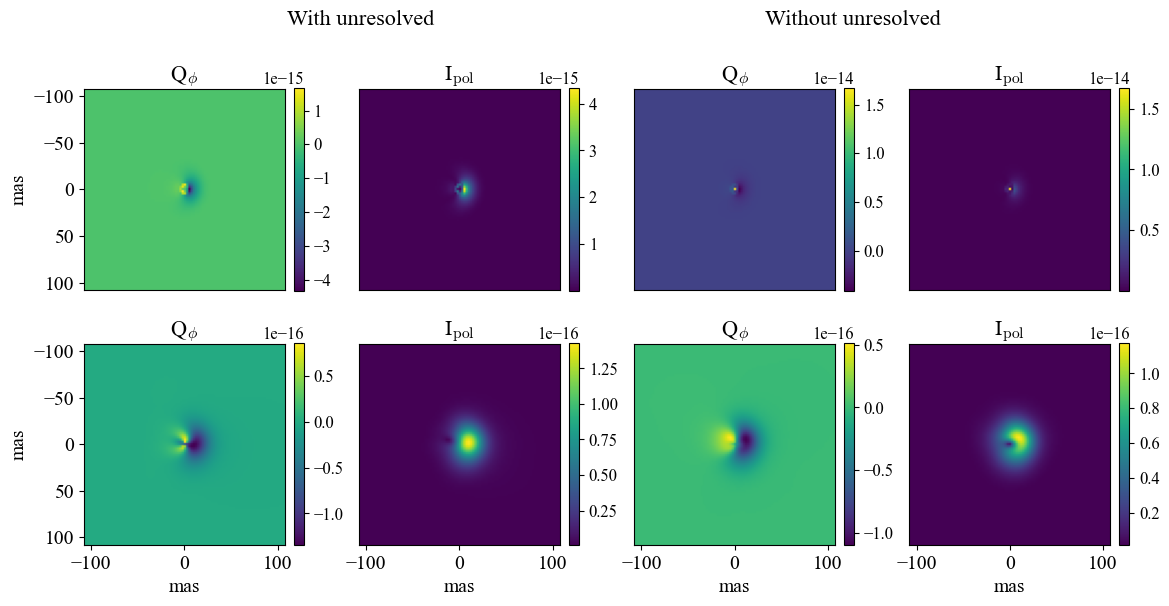

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Optional, Tuple
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable




images_list = [
    q_phi_rescaled, pi_rescaled, q_phi_corr, pi_corr,
    Q_phi_conv, PI_conv, q_phi_corr_conv, pi_corr_conv
]
titles = ['Q$_\\phi$', 'I$_{\\mathrm{pol}}$', 'Q$_\\phi$', 'I$_{\\mathrm{pol}}$',
          'Q$_\\phi$', 'I$_{\\mathrm{pol}}$', 'Q$_\\phi$', 'I$_{\\mathrm{pol}}$']

print(ps, type(ps))

fig, axs = kf.plot_image_grid(
    images=images_list,
    ps_mas=ps,
    nrows=2,
    ncols=4,
    titles=titles,
    group_headers=[(0.31, 'With unresolved'), (0.72, 'Without unresolved')],
    scale="asinh",
    roi_half_size=30,          
    per_panel_autoscale=True,
    colorbar="individual",
    figsize=(12, 6),
    show=True
)
fig.savefig(fig_dir+"mcfost_model_comparison.png", dpi=150, bbox_inches='tight')


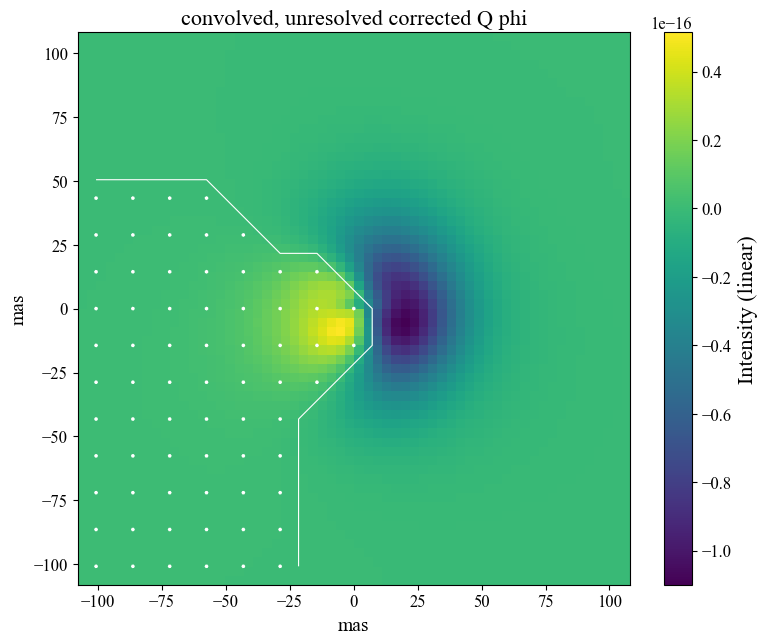

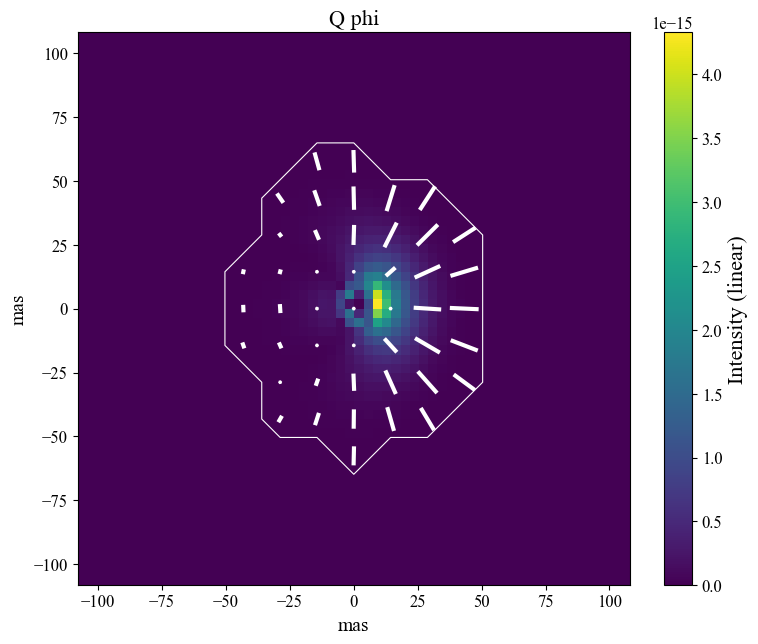

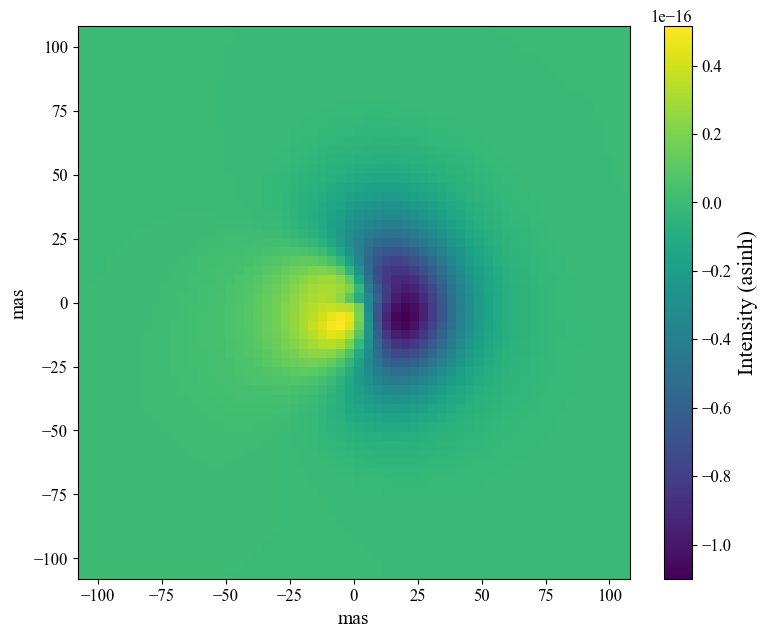

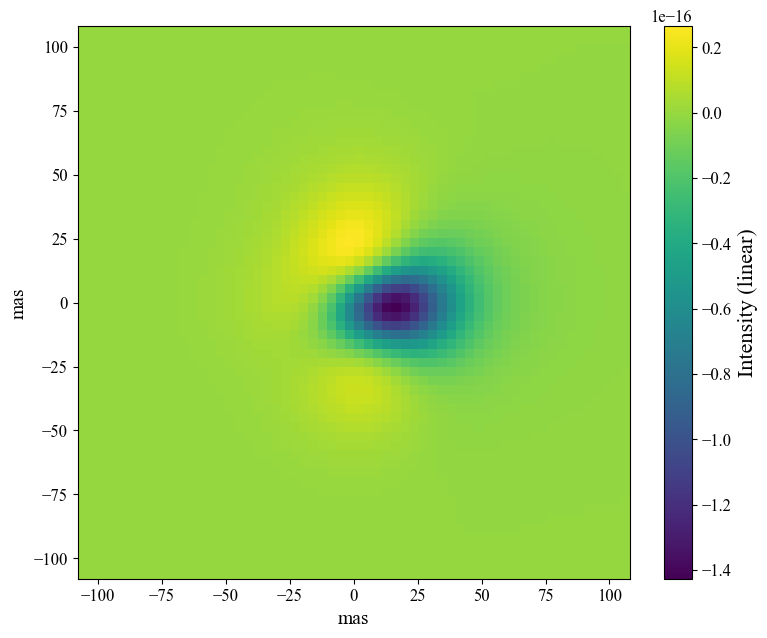

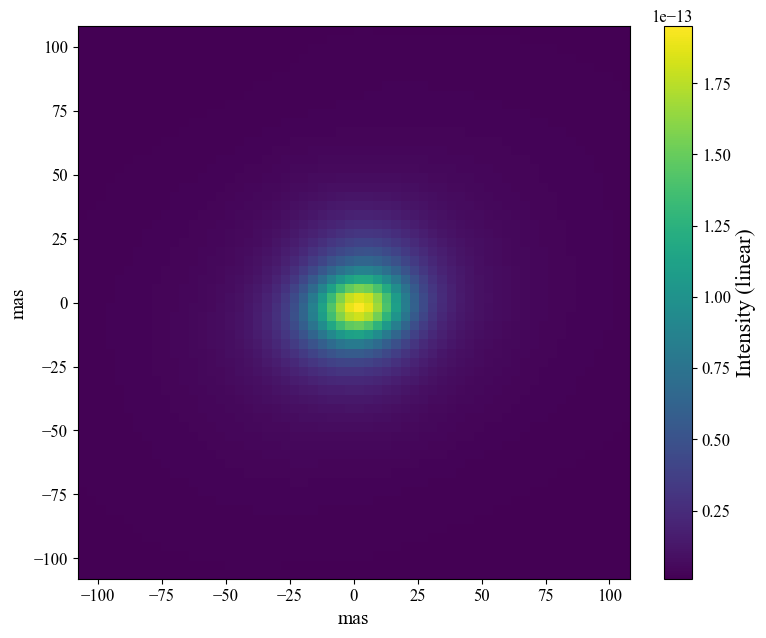

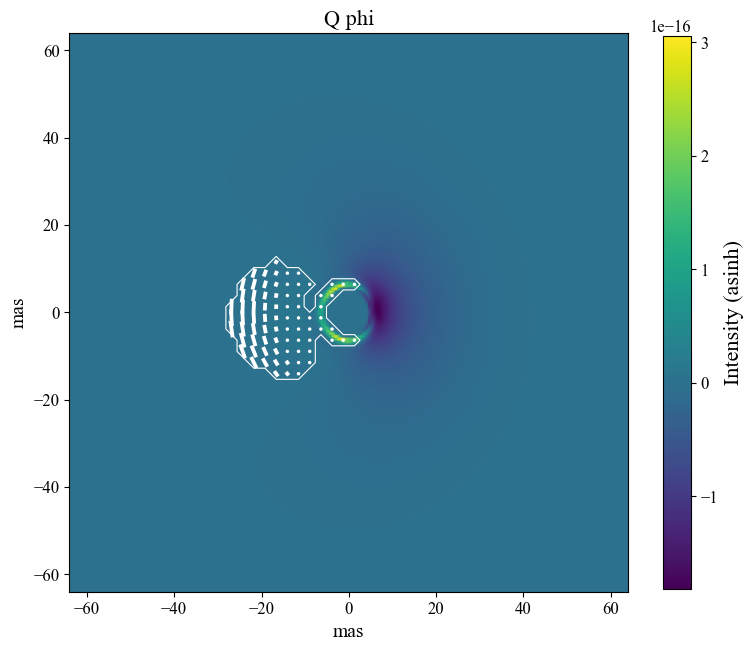

In [9]:

kf.plot_polarimetric_image(q_phi_corr_conv,ps,Q=q_corr_conv,U=u_corr_conv,I=I_conv,title="convolved, unresolved corrected Q phi",bin_factor=(4,4),save=False,snr_threshold=3,noise_level=5e-19,roi_half_size=30,aolp_quiver=True, quiver_scale=0.1)
kf.plot_polarimetric_image(pi_rescaled,ps,Q=img_q_rescaled,U=img_u_rescaled,I=img_total_rescaled,title="Q phi",bin_factor=(4,4),save=False,snr_threshold=3,noise_level=2e-17,roi_half_size=30,aolp_quiver=True, quiver_scale=5)
kf.plot_polarimetric_image(q_phi_corr_conv, ps, roi_half_size=30, image_scale="asinh")
kf.plot_polarimetric_image(Q_conv, ps, roi_half_size=30, image_scale="linear")
kf.plot_polarimetric_image(I_conv, ps, roi_half_size=30, image_scale="linear")

kf.plot_polarimetric_image(q_phi,pixel_scale,Q=img_q,U=img_u,I=img_tot,title="Q phi",bin_factor=(4,4),image_scale="asinh",save=False,snr_threshold=3,noise_level=1e-17,roi_half_size=100,aolp_quiver=True, quiver_scale=3)



## Radial profile

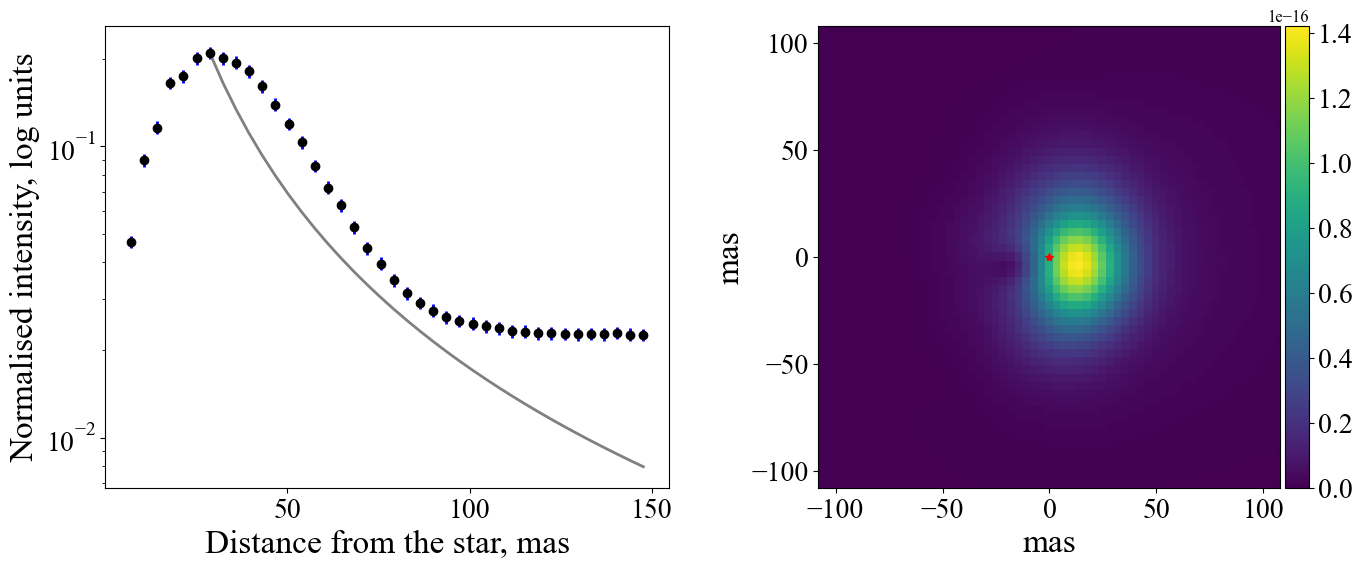

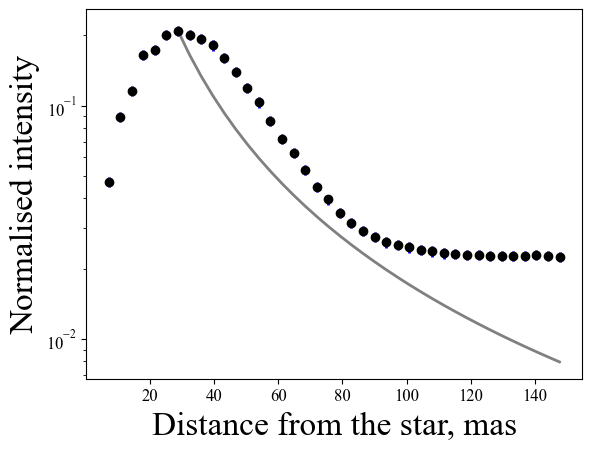

In [10]:
radial_profile_1=kf.radial_br_profile(PI_conv, ps,incl,pa, R_limit=150, noise_level=0.05,force_stop=True, mode='sum',save=fig_dir+"mcfost_", plot=True,background_annulus_mas=(200,250))

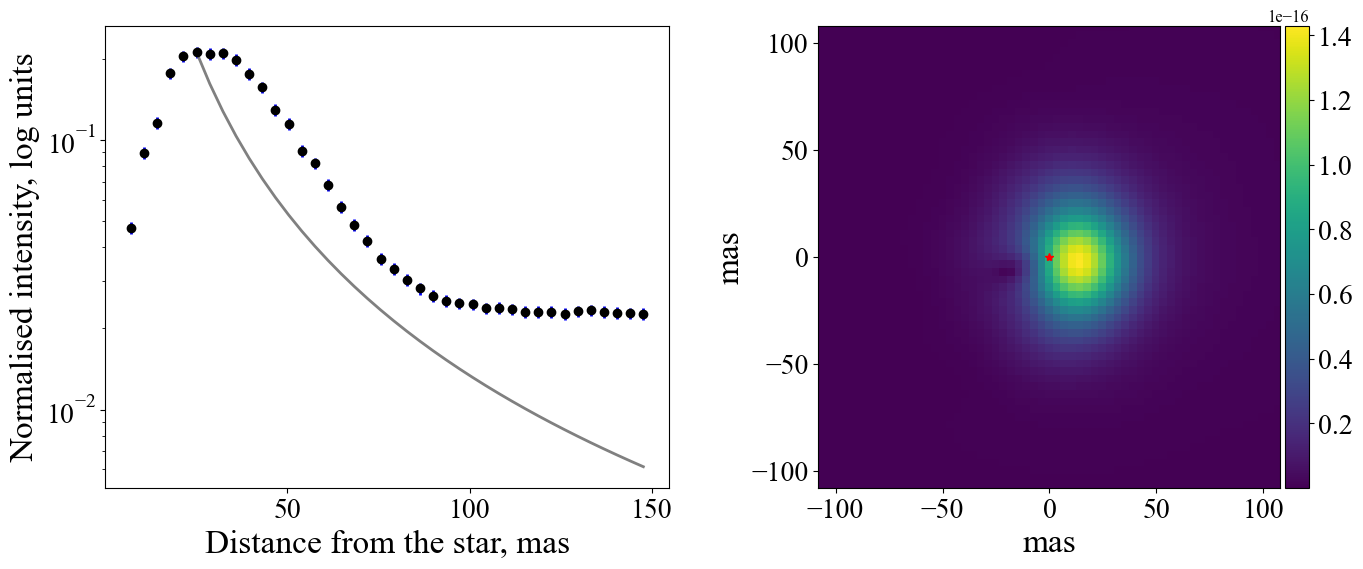

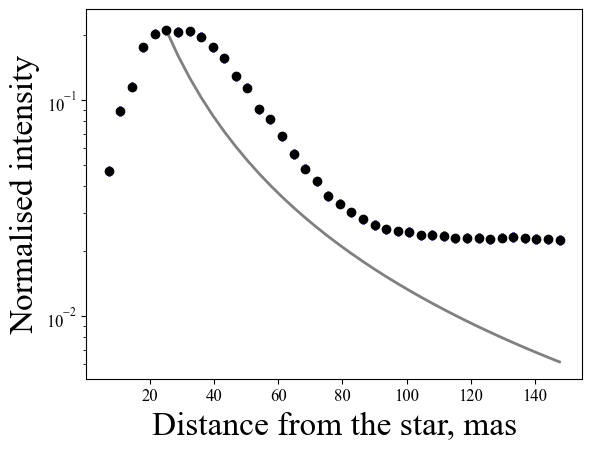

In [20]:
radial_profile_0=kf.radial_br_profile(PI_conv, ps,0,0,R_limit=150, noise_level=0.05, mode='sum', force_stop=True, save=fig_dir+"mcfost_", plot=True,background_annulus_mas=(200,250))

In [13]:
PI_conv.shape

(91, 91)

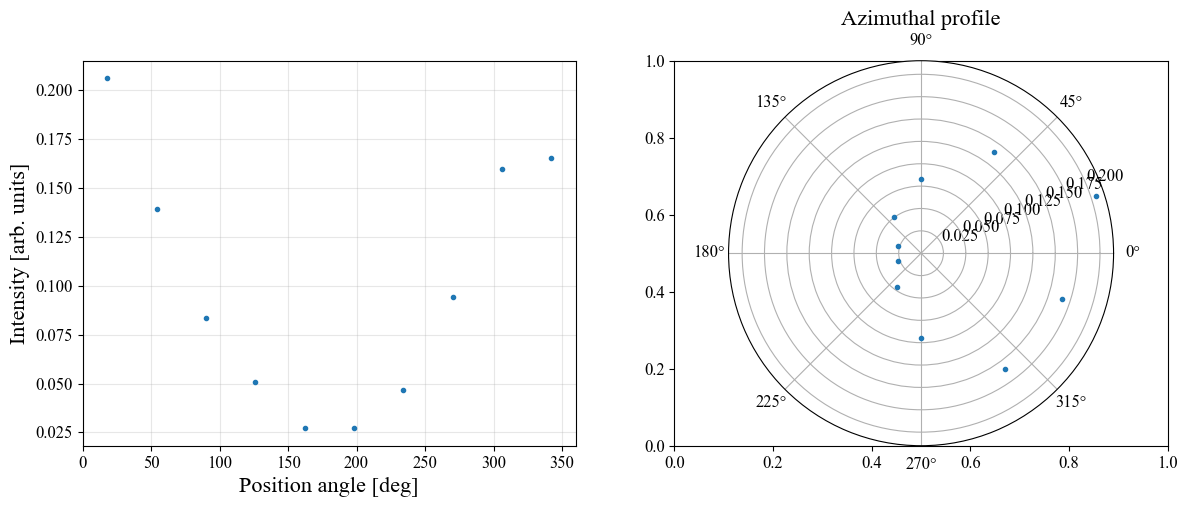

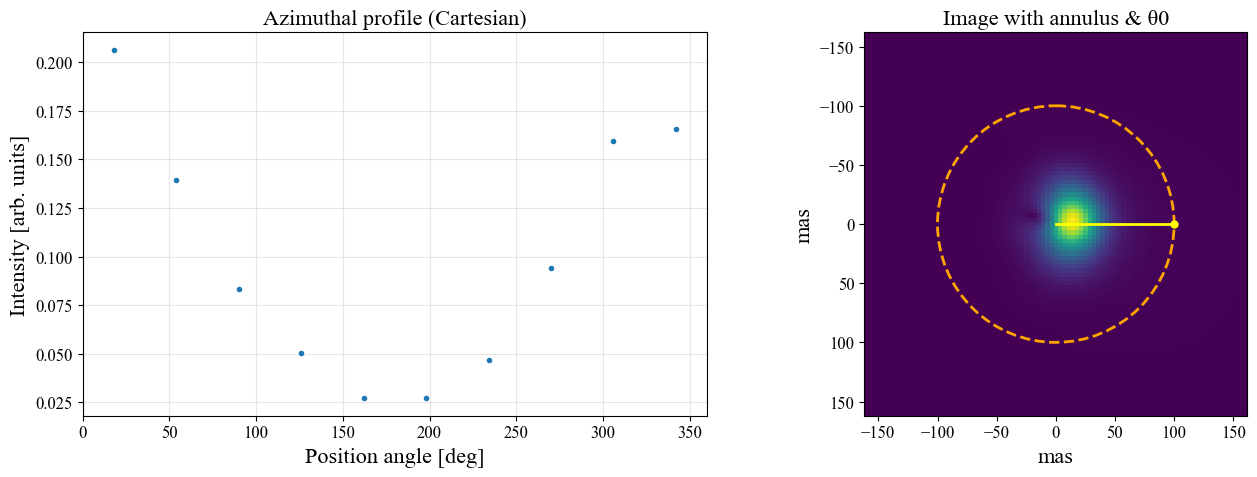

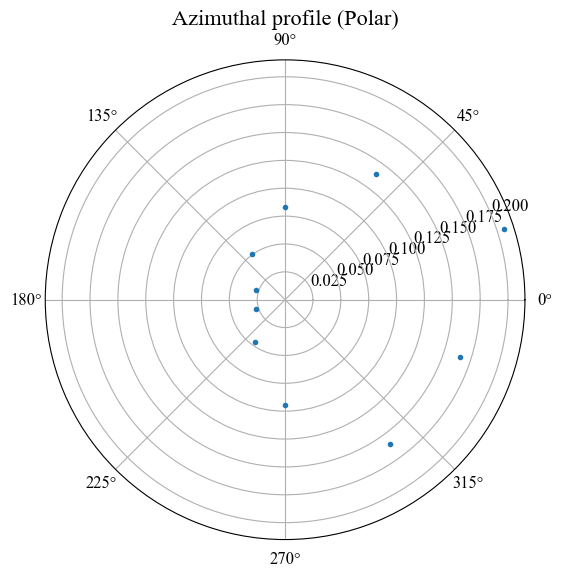

In [17]:
az_profile=kf.azimuthal_profile(PI_conv, ps, r_in_mas=0, r_out_mas=100, plot=True,mode='sum', save=fig_dir+"mcfost_", nbins=10, theta0=0)